## Step 0: Library Imports

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

## Step 1: Data Augmentation

In [2]:
# Define data augmentation rules
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

## Step 2: Data Loading

In [3]:
# Define image dimensions and batch size
batch_size = 32
img_size = (224, 224)

# Initialize data generators
train_generator = train_datagen.flow_from_directory(
    'aircraft_damage_dataset_v1/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    'aircraft_damage_dataset_v1/valid',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    'aircraft_damage_dataset_v1/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 300 images belonging to 2 classes.
Found 96 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


## Step 3: Model Architecture

In [4]:
# Build the model using a frozen VGG16 base and a custom classification head
input_shape = img_size + (3,)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

output = base_model.layers[-1].output
output = GlobalAveragePooling2D()(output)
base_model = Model(base_model.input, output)

base_model.trainable = False

model = Sequential()
model.add(base_model)
model.add(Dense(512, 'relu'))
model.add(Dropout(0.3))
model.add(Dense(512, 'relu'))
model.add(Dropout(0.3))
model.add(Dense(1, 'sigmoid'))

## Step 4: Model Compilation and Training

In [5]:
# Compile model
model.compile(optimizer=Adam(0.00005), loss='binary_crossentropy', metrics=['accuracy'])

# Initialize early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=valid_generator,
    callbacks=[early_stop]
).history

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4767 - loss: 1.3055 - val_accuracy: 0.4583 - val_loss: 0.8242
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4967 - loss: 1.1736 - val_accuracy: 0.5521 - val_loss: 0.7169
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5633 - loss: 1.1484 - val_accuracy: 0.6354 - val_loss: 0.6779
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6167 - loss: 0.9619 - val_accuracy: 0.6458 - val_loss: 0.6107
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5700 - loss: 0.9398 - val_accuracy: 0.6875 - val_loss: 0.5976
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6400 - loss: 0.8696 - val_accuracy: 0.6771 - val_loss: 0.6360
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6067 - loss: 0.8572 - val_accuracy: 0.6875 - val_loss: 0.6083
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6267 - loss: 0.8011 - val_accuracy: 0.6979 - val_loss:

## Step 5: Loss and Accuracy Visualization

In [6]:
# Extract best epoch metrics for plotting
epochs = range(1, early_stop.stopped_epoch + 2)
best_epoch = early_stop.best_epoch
best_val_acc = history['val_accuracy'][best_epoch]
best_val_loss = history['val_loss'][best_epoch]

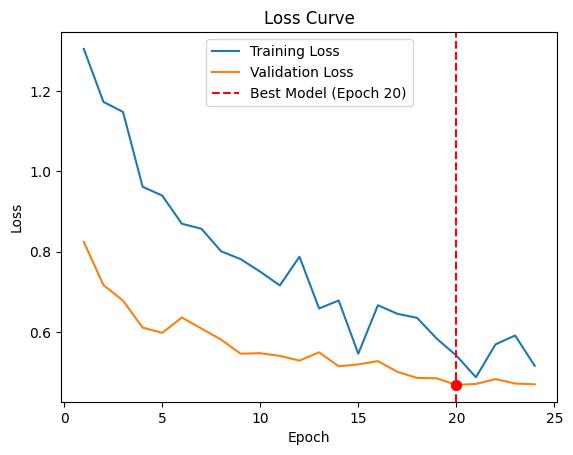

In [7]:
# Loss visualization
plt.plot(epochs, history['loss'], label='Training Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.axvline(best_epoch+1, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
plt.scatter(best_epoch+1, best_val_loss, color='red', s=50, zorder=2)
plt.title('Loss Curve')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

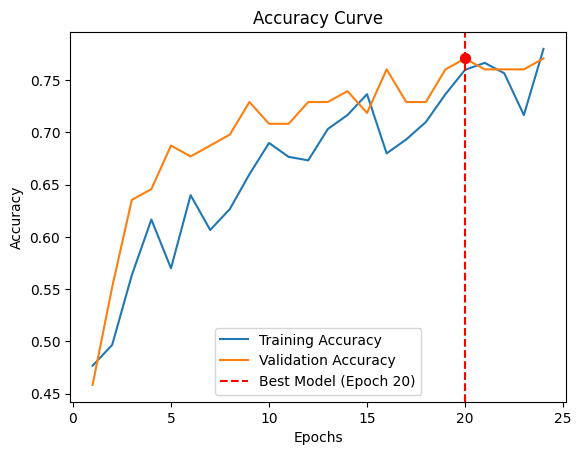

In [8]:
# Accuracy visualization
plt.plot(epochs, history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
plt.axvline(best_epoch+1, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
plt.scatter(best_epoch+1, best_val_acc, color='red', s=50, zorder=2)
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Step 6: Model Evaluation

In [9]:
# Evaluate the model using test dataset
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8438 - loss: 0.6503
Test Loss: 0.6503
Test Accuracy: 0.8438
